# HW3 - Introduction to Image Processing Course


## 1. Environment Setup and Preparations

Import libraries

In [55]:
import sys
import os
import cv2
import random
import matplotlib.pyplot as plt
from matplotlib.image import imread, imsave
import pandas as pd
import numpy as np
import tensorflow as tf
import skimage as ski
from skimage.io import imread
from skimage import img_as_float
from skimage import exposure
from PIL import Image
import six.moves.urllib as urllib
import tarfile
import zipfile


Libraries versions

In [56]:
print('pandas version: '+ pd.__version__)
print('numpy version: '+np.__version__)
print('tensorflow version: '+tf.__version__)
print('scikit-image version: '+ski.__version__)

pandas version: 2.2.2
numpy version: 1.26.4
tensorflow version: 2.17.0
scikit-image version: 0.24.0


In [57]:
conda_env = os.environ.get('CONDA_DEFAULT_ENV')
print(f"current Conda environment: '{conda_env}'.")

current Conda environment: 'image_processing_env'.


`image_common_utils` functions

In [58]:
# Description: It displays many images in one row
def imshow_all(*images, titles=None):
    images = [img_as_float(img) for img in images]

    if titles is None:
        titles = [''] * len(images)
    vmin = min(map(np.min, images))
    vmax = max(map(np.max, images))
    ncols = len(images)
    height = 5
    width = height * len(images)
    fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(width, height))
    for ax, img, label in zip(axes.ravel(), images, titles):
        ax.imshow(img, vmin=vmin, vmax=vmax)
        ax.set_title(label)

    return
    # end of imshow_all

# Description: It displays many images in many rows and column
# cmap='gray'; row_plot = 1; img= [img, camera]
def show_image(image, title="Image"):
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()
    return
# end of show_image


`import_image` function to import images

In [59]:
def import_image (path):
    img = imread(path)
    img.shape  # H x W x C
    img.size  # multiplication of HxWxC
    type(img)
    img.dtype
    return(img)

## 2. Face Detection andn Recoginition

In [60]:
training_data_folder_path = './images_data/train-data'
test_data_folder_path = './images_data/test-data'

In [61]:
tags = ['Tamir']

In [62]:
def detect_face(input_img):
    gray_image = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier('./models/haarcascade_frontalface.xml')
    faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.2, minNeighbors=5)
    if len(faces) == 0:
        return -1, -1
    (x, y, w, h) = faces[0]
    return gray_image[y:y+h, x:x+w], faces[0]

In [91]:
def detect_eyes(input_img):
    img = input_img.copy()
    gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_image = cv2.equalizeHist(gray_image)  # Improve contrast

    eye_cascade = cv2.CascadeClassifier('./models/haarcascade_eye.xml')
    eyes_rects = eye_cascade.detectMultiScale(
        gray_image,
        scaleFactor=1.05,  # Test smaller values for more precision
        minNeighbors=7,   # Lower to capture more potential eyes
        minSize=(20, 20),  # Minimum size of detected eyes
        maxSize=(100, 100)  # Maximum size of detected eyes
    )

    for (x, y, w, h) in eyes_rects:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return img


In [64]:
def prepare_training_data(training_data_folder_path):
    detected_faces = []
    face_labels = []
    training_image_dirs = os.listdir(training_data_folder_path)
    
    for dir_name in training_image_dirs:
        label = int(dir_name)  # Assuming folder names are labels (e.g., "0", "1")
        training_image_path = os.path.join(training_data_folder_path, dir_name)
        training_images_names = os.listdir(training_image_path)
        
        for image_name in training_images_names:
            image_path = os.path.join(training_image_path, image_name)
            image = cv2.imread(image_path)
            face, rect = detect_face(image)
            if face is not -1:
                resized_face = cv2.resize(face, (121, 121), interpolation=cv2.INTER_AREA)
                detected_faces.append(resized_face)
                face_labels.append(label)

    return detected_faces, face_labels

<>:15: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:15: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/tmp/ipykernel_5192/3520490711.py:15: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if face is not -1:


In [65]:
def draw_rectangle(test_image, rect):
    (x, y, w, h) = rect
    cv2.rectangle(test_image, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Function to draw text on the image
def draw_text(test_image, label_text, x, y):
    cv2.putText(test_image, label_text, (x, y), cv2.FONT_HERSHEY_PLAIN, 2, (0, 255, 0), 2)

In [66]:
def predict(test_image):
    detected_face, rect = detect_face(test_image)
    if detected_face is -1:
        return test_image, "Unknown"
    
    resized_test_image = cv2.resize(detected_face, (121, 121), interpolation=cv2.INTER_AREA)
    label = eigenfaces_recognizer.predict(resized_test_image)
    label_text = tags[label[0]]
    draw_rectangle(test_image, rect)
    draw_text(test_image, label_text, rect[0], rect[1] - 5)
    return test_image, label_text

<>:3: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:3: SyntaxWarning: "is" with a literal. Did you mean "=="?
/tmp/ipykernel_5192/1834590559.py:3: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if detected_face is -1:


In [67]:
def process_image(image_path):
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not open image file {image_path}")
        return

    # Predict faces in the image
    predicted_image, predicted_labels = predict(image)
        
    # Display the result
    show_image(predicted_image, title=f"Predicted Image")



In [68]:
def process_video(video_path):
    # Open the video file
    video_capture = cv2.VideoCapture(video_path)
    
    if not video_capture.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return
    
    # Loop through frames
    while True:
        ret, frame = video_capture.read()
        if not ret:
            break  # End of video

        # Predict faces in the current frame
        predicted_frame, predicted_labels = predict(frame)

        # Show the frame with predictions
        cv2.imshow("Video Face Recognition", predicted_frame)

        # Break on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release the video capture and close display window
    video_capture.release()
    cv2.destroyAllWindows()

In [69]:
detected_faces, face_labels = prepare_training_data(training_data_folder_path)

In [70]:
eigenfaces_recognizer = cv2.face.EigenFaceRecognizer_create()
eigenfaces_recognizer.train(detected_faces, np.array(face_labels))

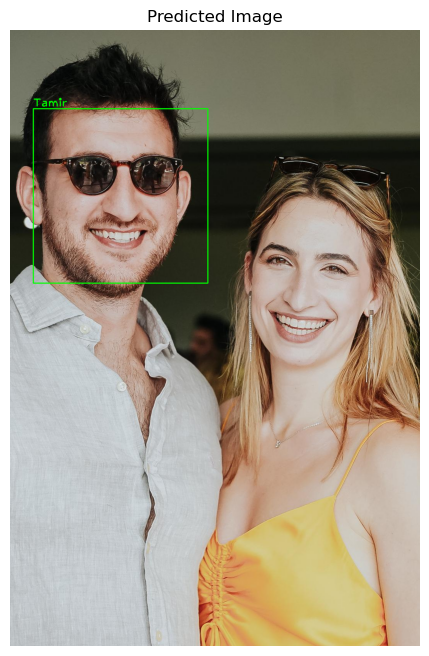

In [81]:
image_path = "./images_data/test-data/0/test1.jpg"

# Process the image
process_image(image_path)

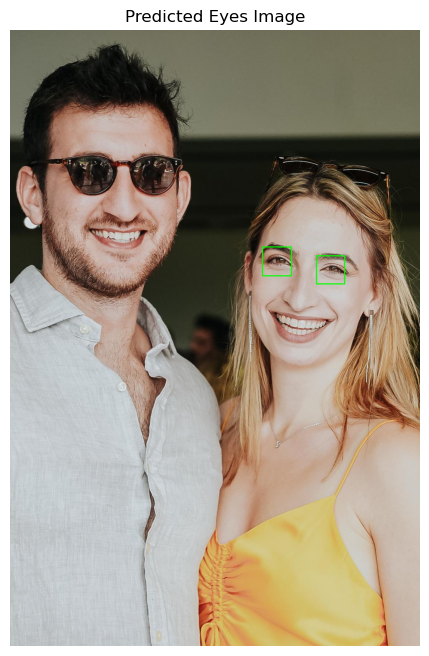

In [93]:
image_path = "./images_data/test-data/0/test1.jpg"
img = cv2.imread(image_path)
eyes_img = detect_eyes(img)
show_image(eyes_img, title=f"Predicted Eyes Image")

In [30]:
# Path to the video file
video_path = "./images_data/test-data/0/test4.mp4"

# Process the video
process_video(video_path)

QObject::moveToThread: Current thread (0x584625376fa0) is not the object's thread (0x584625748260).
Cannot move to target thread (0x584625376fa0)

QObject::moveToThread: Current thread (0x584625376fa0) is not the object's thread (0x584625748260).
Cannot move to target thread (0x584625376fa0)

QObject::moveToThread: Current thread (0x584625376fa0) is not the object's thread (0x584625748260).
Cannot move to target thread (0x584625376fa0)

QObject::moveToThread: Current thread (0x584625376fa0) is not the object's thread (0x584625748260).
Cannot move to target thread (0x584625376fa0)

QObject::moveToThread: Current thread (0x584625376fa0) is not the object's thread (0x584625748260).
Cannot move to target thread (0x584625376fa0)

QObject::moveToThread: Current thread (0x584625376fa0) is not the object's thread (0x584625748260).
Cannot move to target thread (0x584625376fa0)

QObject::moveToThread: Current thread (0x584625376fa0) is not the object's thread (0x584625748260).
Cannot move to tar

## 3. Object Detection

## 3. Segmentation